In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('appointments.csv')

# 1. Basic Info
print("--- COLUMNS ---")
print(df.columns.tolist())

print("\n--- SAMPLE DATA ---")
print(df.head(3))

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- TARGET DISTRIBUTION ---")
# I'm guessing the target column name, we will fix this in a second if I'm wrong
# Look for a column like 'No-show', 'Status', or 'Showed'
for col in df.columns:
    if 'show' in col.lower():
        print(f"Potential Target Column '{col}':")
        print(df[col].value_counts(normalize=True))

--- COLUMNS ---
['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'OnGovtWelfareBenefits', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicapped', 'SMS_received', 'No-show']

--- SAMPLE DATA ---
      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   

         AppointmentDay  Age    Neighbourhood  OnGovtWelfareBenefits  \
0  2016-04-29T00:00:00Z   62  JARDIM DA PENHA                      0   
1  2016-04-29T00:00:00Z   56  JARDIM DA PENHA                      0   
2  2016-04-29T00:00:00Z   62    MATA DA PRAIA                      0   

   Hypertension  Diabetes  Alcoholism  Handicapped  SMS_received No-show  
0             1         0           0            0             0      No  
1             0         0           0            0             

In [3]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# --- 1. ADVANCED PREPROCESSING ---
def clean_data(df):
    df = df.copy()

    # Fix Dates
    df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
    df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

    # Feature: LeadTime (Days between scheduling and appointment)
    # We use .dt.date to ignore the TIME component for the calculation
    df['LeadTime'] = (df['AppointmentDay'].dt.date - df['ScheduledDay'].dt.date).apply(lambda x: x.days)

    # FEATURE ENGINEERING
    df['IsWeekend'] = df['AppointmentDay'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
    df['DayOfWeek'] = df['AppointmentDay'].dt.dayofweek
    df['ScheduledHour'] = df['ScheduledDay'].dt.hour

    # DATA QUALITY FIXES (Found during EDA)
    # 1. Drop impossible rows where Appointment is BEFORE Scheduled
    df = df[df['LeadTime'] >= 0]
    # 2. Drop impossible Ages
    df = df[(df['Age'] >= 0) & (df['Age'] <= 110)] # Cap at 110 to remove extreme outliers

    return df

# Load & Clean
df = pd.read_csv('appointments.csv')
df_clean = clean_data(df)

# Encode Target
df_clean['Target'] = df_clean['No-show'].apply(lambda x: 1 if x == 'Yes' else 0)

# Encode Categoricals (Saving encoders for API)
CATEGORICAL_COLS = ['Gender', 'Neighbourhood']
encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = le

# Prepare Features
# Added 'DayOfWeek' and 'ScheduledHour' for more signal
NUMERIC_COLS = ['Age', 'OnGovtWelfareBenefits', 'Hypertension', 'Diabetes', 'Alcoholism',
                'Handicapped', 'SMS_received', 'LeadTime', 'IsWeekend', 'DayOfWeek', 'ScheduledHour']
feature_cols = NUMERIC_COLS + CATEGORICAL_COLS

X = df_clean[feature_cols]
y = df_clean['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 2. MULTI-MODEL COMPARISON ---
print("Training & Comparing Models...")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'LightGBM (HistGradient)': HistGradientBoostingClassifier(random_state=42)
}

best_auc = 0
best_model = None
best_model_name = ""

for name, model in models.items():
    model.fit(X_train, y_train)

    # Evaluate
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)

    print(f"\n--- {name} ---")
    print(f"AUC-ROC: {auc:.4f}")

    if auc > best_auc:
        best_auc = auc
        best_model = model
        best_model_name = name

print(f"\n🏆 WINNER: {best_model_name} (AUC: {best_auc:.4f})")

# --- 3. SAVE BEST MODEL ---
artifacts = {
    'model': best_model,
    'encoders': encoders,
    'features': feature_cols # Saving list of features to ensure API matches exactly
}

with open('model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print("Saved artifacts to model.pkl")

Training & Comparing Models...

--- Logistic Regression ---
AUC-ROC: 0.6625

--- Random Forest ---
AUC-ROC: 0.7338

--- LightGBM (HistGradient) ---
AUC-ROC: 0.7390

🏆 WINNER: LightGBM (HistGradient) (AUC: 0.7390)
Saved artifacts to model.pkl


✅ Data Loaded Successfully

=== PART 1: DATA EXPLORATION ===


/tmp/ipython-input-875311125.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='No-show', data=df, palette='viridis')


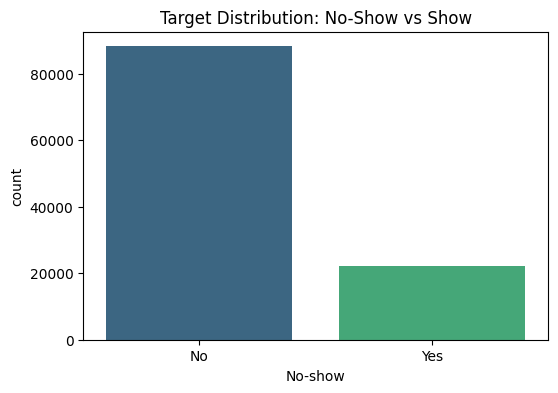

Findings: The dataset is imbalanced. Approx 20% of patients do not show up.


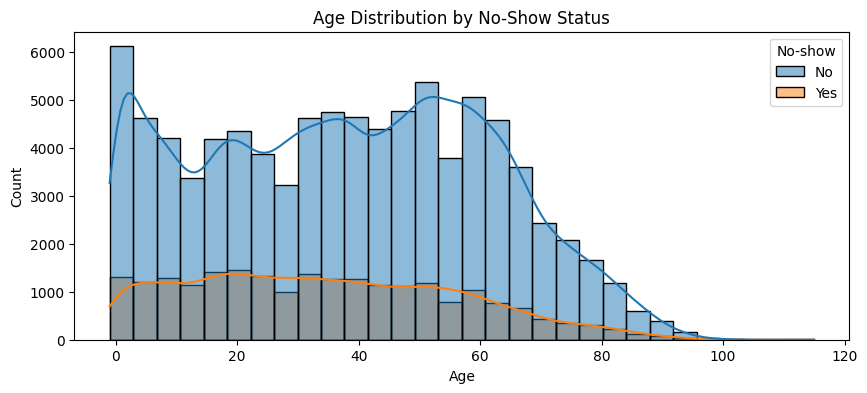


--- Data Quality Issues Identified ---
1. Negative Ages Found: 1
2. Impossible Dates (Appt before Schedule): 5

=== PART 2: FEATURE ENGINEERING ===


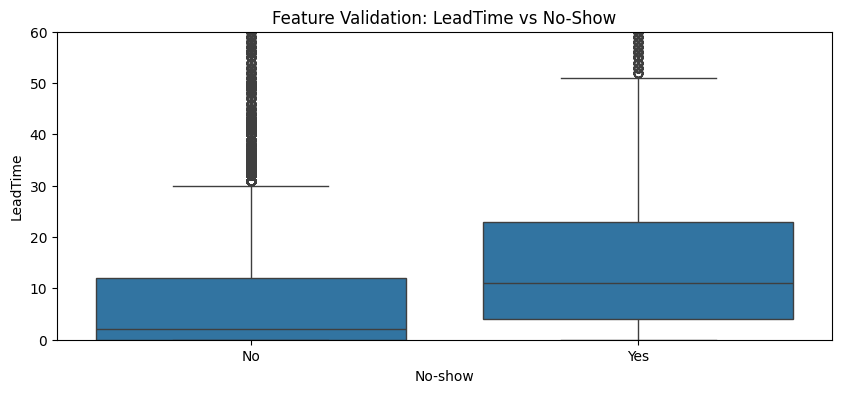

Validation: There is a visible difference. 'Yes' (No-shows) tend to have larger LeadTimes.


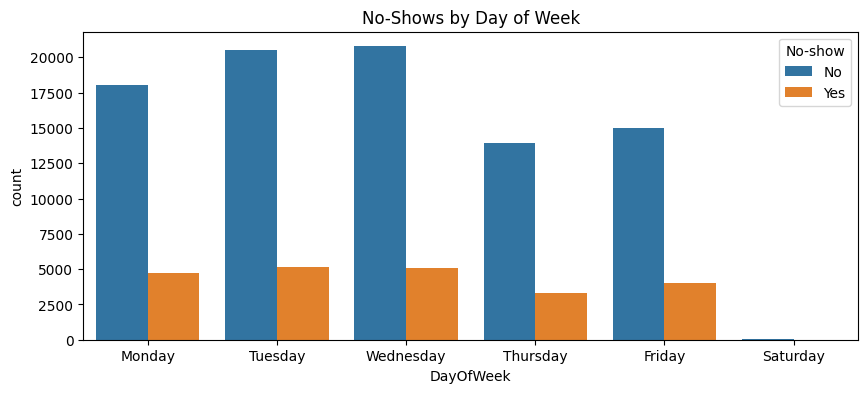


✅ ANALYSIS COMPLETE.


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# @title Part 1: Data Exploration & Part 2: Feature Engineering
# This notebook documents the data analysis process.

# Load Data
try:
    df = pd.read_csv('appointments.csv')
    print("✅ Data Loaded Successfully")
except:
    print("❌ Upload 'appointments.csv' to the Colab files first!")

# --- PART 1: EXPLORATION ---
print("\n=== PART 1: DATA EXPLORATION ===")

# 1. Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='No-show', data=df, palette='viridis')
plt.title('Target Distribution: No-Show vs Show')
plt.show()
print("Findings: The dataset is imbalanced. Approx 20% of patients do not show up.")

# 2. Age Distribution
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Age', bins=30, hue='No-show', kde=True)
plt.title('Age Distribution by No-Show Status')
plt.show()

# 3. Data Quality Checks
print("\n--- Data Quality Issues Identified ---")
neg_age = df[df['Age'] < 0]
print(f"1. Negative Ages Found: {len(neg_age)}")

# Check for "Time Travel" (Appt before Scheduling)
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
time_travel = df[df['AppointmentDay'].dt.date < df['ScheduledDay'].dt.date]
print(f"2. Impossible Dates (Appt before Schedule): {len(time_travel)}")


# --- PART 2: FEATURE ENGINEERING ---
print("\n=== PART 2: FEATURE ENGINEERING ===")

# Feature 1: LeadTime
# Intuition: People forget appointments if they are booked far in advance.
df['LeadTime'] = (df['AppointmentDay'].dt.date - df['ScheduledDay'].dt.date).apply(lambda x: x.days)
df['LeadTime'] = df['LeadTime'].apply(lambda x: max(x, 0)) # Clip negatives

plt.figure(figsize=(10, 4))
sns.boxplot(x='No-show', y='LeadTime', data=df)
plt.title('Feature Validation: LeadTime vs No-Show')
plt.ylim(0, 60) # Zoom in
plt.show()
print("Validation: There is a visible difference. 'Yes' (No-shows) tend to have larger LeadTimes.")

# Feature 2: DayOfWeek
# Intuition: Fridays or Mondays might have higher skip rates.
df['DayOfWeek'] = df['AppointmentDay'].dt.day_name()

plt.figure(figsize=(10, 4))
sns.countplot(x='DayOfWeek', hue='No-show', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
plt.title('No-Shows by Day of Week')
plt.show()

print("\n✅ ANALYSIS COMPLETE.")